# Distilling a Cyclohexane Potential from a DPA3 Pretrained Model


<a href="https://ustc.bohrium.com/notebooks/99176325231/" target="_blank"><img src="https://cdn.dp.tech/bohrium/web/static/images/open-in-bohrium.svg" alt="Open In Bohrium"/></a>


This tutorial demonstrates how to distill a compact Deep Potential model for cyclohexane from a DPA3 pretrained Teacher model. It is adapted from the experimental materials of the *Artificial Intelligence and Molecular Science* course at the University of Science and Technology of China.

The workflow uses the pretrained **DPA-3.2-5M** model as the Teacher potential. We first run molecular dynamics (MD) for cyclohexane with the Teacher model, then extract configurations from the trajectory together with the Teacher-predicted energy, force, and virial labels. Finally, we train a smaller Student DeePMD model that reproduces the Teacher response within the sampled cyclohexane configuration space and use the Student model for a longer MD simulation.

- **DPA3**: a DeePMD-kit atomic environment representation that combines atomic, radial, and angular information to describe local chemical environments.

- **Knowledge distillation**: a model-compression strategy. In this tutorial, the Student model learns Teacher-predicted energy and force labels, not direct DFT labels. The goal is to approximate the Teacher potential for a specific molecular system at a lower inference cost.

**Workflow:**

1. Generate an initial cyclohexane structure.
2. Run Teacher MD with the DPA3 pretrained model.
3. Extract configurations and Teacher energy / force / virial labels.
4. Build a DeePMD training dataset.
5. Train a compact Student potential.
6. Run longer MD with the Student potential.

Cyclohexane is a convenient documentation example because it is a small organic molecule with only C and H atoms, so the calculation is fast enough for a tutorial. However, a short unbiased MD trajectory started from one initial structure should not be interpreted as a complete conformational search. At room temperature it will usually remain in the chair basin. Observing rare ring-flip events or a statistically meaningful population of boat and twist-boat conformers requires much longer trajectories, higher-temperature sampling, or enhanced-sampling methods. This tutorial therefore uses cyclohexane mainly to demonstrate the distillation workflow and to visualize representative structures within the sampled region.


```{contents} Table of Contents
:depth: 3
```


## Install the required packages

DeePMD-kit supports multiple backends. Because the pretrained weights used here are based on PyTorch, this tutorial installs the PyTorch backend.


In [2]:
!pip install deepmd-kit[torch] dpdata ase matplotlib openbabel-wheel py3Dmol tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 60.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 14.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 24.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:0000:0100:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 63.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 84.0

## Import dependencies

This section imports the Python packages used later in the tutorial. The imports are intentionally kept close to the beginning so that missing packages fail early.

**Standard library modules:**
- `json`: read and write JSON configuration files.
- `os`: query system information and paths.
- `subprocess`: run external commands when needed.
- `time`: measure elapsed time.
- `pathlib.Path`: handle paths in a platform-independent way.

**Third-party packages:**
- `numpy`: numerical arrays and analysis.
- `dpdata`: data conversion and DeePMD dataset writing.


In [3]:
from pathlib import Path

import numpy as np
import dpdata

## Prepare the Teacher model weights

The distillation workflow requires a pretrained model as the **Teacher** potential. This tutorial uses the publicly available **DPA-3.2-5M** model.

Run the following cell to download the weights and copy them into a local `weights/` directory.


In [4]:
%%bash
set -euo pipefail

dp pretrained download DPA-3.2-5M
mkdir -p weights
cp "$HOME/.cache/deepmd/pretrained/models/DPA-3.2-5M.pt" "weights/DPA-3.2-5M.pt"


[2026-06-20 21:19:18,866] DEEPMD INFO    Selecting fastest source among 3 candidates...
[2026-06-20 21:19:18,866] DEEPMD INFO    Downloading 'DPA-3.2-5M' (source 1/3): https://modelscope.cn/models/DeepModelingCommunity/DPA-3.2-5M/resolve/master/DPA-3.2-5M.pt
[2026-06-20 21:19:23,383] DEEPMD INFO    Downloaded 'DPA-3.2-5M' to: /root/.cache/deepmd/pretrained/models/DPA-3.2-5M.pt
[2026-06-20 21:19:23,383] DEEPMD INFO    Pretrained model path: /root/.cache/deepmd/pretrained/models/DPA-3.2-5M.pt
/root/.cache/deepmd/pretrained/models/DPA-3.2-5M.pt


Inspect the available model branches and the type map.

DPA-3.2-5M is a multitask model. The cells below first list the available branches and type map. The Teacher MD later uses the `OMol25` branch explicitly because cyclohexane is an organic molecular system.


In [5]:
!dp --pt show weights/DPA-3.2-5M.pt model-branch type-map

[2026-06-20 21:19:30,456] DEEPMD WARNING To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
[2026-06-20 21:19:37,012] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
[2026-06-20 21:19:40,636] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
[2026-06-20 21:19:40,636] DEEPMD INFO    This is a multitask model
[2026-06-20 21:19:40,637] DEEPMD INFO    Available model branches are ['OMat24', 'OMol25', 'OC20M', 'Alloy_APEX', 'Domains_Alloy', 'Alex2D', 'ODAC23', 'Organic_Reactions', 'OC22', 'MPTrj', 'SSE_ABACUS', 'Domains_SSE_PBE', 'Electrolyte', 'Domains_SemiCond', 'Domains_A

## Prepare the distillation dataset

This section uses Open Babel to generate an initial cyclohexane structure from a SMILES string. It then runs MD with the DPA3 Teacher model through the ASE calculator interface, samples configurations from the trajectory, and writes a DeePMD-kit training dataset.

The workflow is:

1. Convert the cyclohexane SMILES string into an initial 3D XYZ structure.
2. Run a Teacher MD trajectory with the DPA3 pretrained model.
3. Sample configurations from the trajectory and store Teacher-predicted energy, force, and virial labels.
4. Write the sampled configurations as a DeePMD training dataset.
5. Produce `coord.npy`, `box.npy`, `energy.npy`, `force.npy`, `virial.npy`, `type.raw`, and `type_map.raw`.

The Student model will learn the Teacher response in the configuration region visited by this MD trajectory.


### Generate an initial 3D structure from a SMILES string

Open Babel converts the cyclohexane SMILES string into an initial 3D XYZ structure. This structure is used as the starting point for the Teacher MD simulation.


In [6]:
initial_smiles = "C1CCCCC1"
initial_xyz = Path("data/cyclohexane/raw/cyclohexane_initial.xyz")
initial_xyz.parent.mkdir(parents=True, exist_ok=True)

!obabel -:"{initial_smiles}" -O {initial_xyz} -h --gen3d
print("initial xyz:", initial_xyz)

1 molecule converted
initial xyz: data/cyclohexane/raw/cyclohexane_initial.xyz


In [7]:
!cat data/cyclohexane/raw/cyclohexane_initial.xyz

18

C         -1.42059        0.32798       -0.22055
C         -0.99079       -1.06496        0.23414
C          0.42516       -1.39045       -0.23359
C          1.41996       -0.32808        0.22623
C          0.99446        1.06588       -0.22741
C         -0.42546        1.39336        0.23081
H         -2.41457        0.55707        0.18054
H         -1.50452        0.34555       -1.31413
H         -1.69074       -1.81365       -0.15344
H         -1.03516       -1.12043        1.32884
H          0.44219       -1.45748       -1.32822
H          0.72602       -2.37082        0.15224
H          2.41657       -0.55788       -0.16811
H          1.49594       -0.34832        1.32046
H          1.04706        1.12499       -1.32177
H          1.69167        1.81267        0.16780
H         -0.72489        2.37058       -0.16285
H         -0.44487        1.46853        1.32500


### Run Teacher MD and sample configurations

DeePMD-kit can be used directly as an ASE calculator. After assigning `atoms.calc = DP(...)`, ASE calls the DeePMD model through standard methods such as `get_potential_energy()` and `get_forces()`.

DPA-3.2-5M is a multitask model. The Teacher calculation uses `head="OMol25"`, so the labels come from the Open Molecules 2025 branch.

The default trajectory below uses 5,000 MD steps with a 0.5 fs time step. This is longer than a minimal classroom demo but still practical for a documentation example. It gives the Student model a less trivial local configuration distribution. It is not intended to exhaustively sample cyclohexane ring inversion.

Reference: [DeePMD-kit ASE calculator interface](../third-party/ase.md)


In [8]:
teacher_md_model = Path("weights/DPA-3.2-5M.pt")
teacher_md_head = "OMol25"

from ase import units
from ase.io import read
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet
from deepmd.calculator import DP

In [11]:
RANDOM_SEED = 42
MD_TEMPERATURE_K = 300
MD_TIMESTEP_FS = 0.5
MD_STEPS = 500

In [12]:
atoms_obj = read(str(initial_xyz))
atoms_obj.calc = DP(model=str(teacher_md_model), head=teacher_md_head)

rng = np.random.default_rng(RANDOM_SEED)
MaxwellBoltzmannDistribution(atoms_obj, temperature_K=MD_TEMPERATURE_K, rng=rng)
dynamics = VelocityVerlet(
    atoms_obj,
    timestep=MD_TIMESTEP_FS * units.fs,
    trajectory="md.traj",
    logfile="-",
)

print(f"Running Teacher MD sampling for {MD_STEPS} steps...")
print("teacher model:", teacher_md_model)
print("teacher head:", teacher_md_head)
dynamics.run(MD_STEPS)

You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
Time[ps]      Etot[eV]     Epot[eV]     Ekin[eV]    T[K]
Running Teacher MD sampling for 500 steps...
teacher model: weights/DPA-3.2-5M.pt
teacher head: OMol25
0.0000       -6416.6862   -6417.1005       0.4142   178.0
0.0005       -6416.6862   -6417.0937       0.4076   175.2
0.0010       -6416.6860   -6417.0756       0.3896   167.5
0.0015       -6416.6857   -6417.0492       0.3635   156.2
0.0020       -6416.6855   -6417.0187       0.3332   143.2
0.0025       -6416.6853   -6416.9882       0.3030   130.2
0.0030       -6416.6852   -6416.9611       0.2760   118.6
0.0035       -6416.6852   -6416.9388       0.2536   109.0
0.0040       -6416.6853   -6416.9207       0.2354   101.2
0.0045       -6416.6855   -6416.9051       0.2196    94.4
0.0050       -6416.6856   -6416.8894       0.2039    87.6
0.0055       -6416.6856   -6416.8721       0.1865    80.1
0.006

True

In [13]:
systems = dpdata.LabeledSystem("md.traj", fmt="ase/traj")

preview_stride = max(1, MD_STEPS // 10)
for frame_idx in range(0, len(systems), preview_stride):
    print("frame", frame_idx)
    systems[frame_idx].to_3dmol(
        f_idx=0,
        size=(450, 350),
    ).show()

frame 0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

frame 50


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

frame 100


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

frame 450


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

frame 500


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Save the trajectory as a DeePMD dataset

The `dpdata` package writes the Teacher-labeled trajectory into a DeePMD-kit data directory. The energy, force, and virial labels come from the DPA3 Teacher model used during MD.

Reference: [`dpdata` integration](../third-party/dpdata.md)


In [14]:
systems = dpdata.LabeledSystem("md.traj", fmt="ase/traj")
systems.to_deepmd_npy("data/cyclohexane/train/system_001")

In [15]:
!tree data/cyclohexane/train/system_001

data/cyclohexane/train/system_001
├── nopbc
├── set.000
│   ├── box.npy
│   ├── coord.npy
│   ├── energy.npy
│   └── force.npy
├── type.raw
└── type_map.raw

2 directories, 7 files


## Generate the Student training configuration

The DeePMD-kit training entry point is a JSON configuration file. For clarity, this tutorial writes the configuration to `configs/student_se_atten_v2.json` instead of placing it directly inside the run directory.

If you want to adjust model size, the number of training steps, learning-rate decay, or loss weights, start from the variables and JSON fields in the following cell.

The Student model uses the `se_atten_v2` descriptor and learns the DPA-3 Teacher energy, force, and virial labels for the sampled cyclohexane configurations.


In [16]:
%%bash
set -euo pipefail

mkdir -p configs runs/cyclohexane_dpa3_distill/student_se_atten_v2

cat > configs/student_se_atten_v2.json <<EOF
{
  "model": {
    "type_map": ["C", "H"],
    "descriptor": {
      "type": "se_atten_v2",
      "sel": "auto",
      "rcut_smth": 0.5,
      "rcut": 6.0,
      "neuron": [25, 50, 100],
      "resnet_dt": false,
      "axis_neuron": 16,
      "seed": 1,
      "attn": 128,
      "attn_layer": 0,
      "attn_dotr": true,
      "attn_mask": false,
      "precision": "float32"
    },
    "fitting_net": {
      "neuron": [240, 240, 240],
      "resnet_dt": true,
      "precision": "float32",
      "seed": 1
    }
  },
  "learning_rate": {
    "type": "exp",
    "decay_steps": 10000,
    "start_lr": 1e-3,
    "stop_lr": 1e-5
  },
  "loss": {
    "type": "ener",
    "start_pref_e": 0.02,
    "limit_pref_e": 1.0,
    "start_pref_f": 1000,
    "limit_pref_f": 1.0,
    "start_pref_v": 0,
    "limit_pref_v": 0
  },
  "training": {
    "training_data": {
      "systems": ["$(pwd)/data/cyclohexane/train/system_001"],
      "batch_size": 8
    },
    "numb_steps": 20000,
    "seed": 10,
    "disp_file": "lcurve.out",
    "disp_freq": 200,
    "save_freq": 5000,
    "save_ckpt": "model.ckpt",
    "disp_training": true,
    "time_training": true,
    "profiling": false,
    "profiling_file": "timeline.json"
  }
}
EOF


## Train the Student model

This cell starts DeePMD-kit training.

The input configuration is `configs/student_se_atten_v2.json`. The training outputs are written to `runs/cyclohexane_dpa3_distill/student_se_atten_v2`.


In [17]:
%%bash
set -euo pipefail

STUDENT_INPUT="$(pwd)/configs/student_se_atten_v2.json"
STUDENT_WORKDIR="$(pwd)/runs/cyclohexane_dpa3_distill/student_se_atten_v2"

mkdir -p "$STUDENT_WORKDIR"
cd "$STUDENT_WORKDIR"

dp --pt train "$STUDENT_INPUT"

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
[2026-06-20 22:11:19,616] DEEPMD INFO    DeePMD version: 3.1.3
[2026-06-20 22:11:19,617] DEEPMD INFO    Configuration path: //configs/student_se_atten_v2.json
[2026-06-20 22:11:19,618] DEEPMD INFO     _____               _____   __  __  _____           _     _  _   
[2026-06-20 22:11:19,619] DEEPMD INFO    |  __ \             |  __ \ |  \/  ||  __ \         | |   (_)| |  
[2026-06-20 22:11:19,619] DEEPMD INFO    | |  | |  ___   ___ | |__) || \  / || |  | | ______ | | __ _ | |_ 
[2026-06-20 22:11:19,619] DEEPMD INFO    | |  | | / _ \ / _ \|  ___/ | |\/| || |  | ||______|| |/ /| || __|
[2026-06-20 22:11:19,619] DEEPMD INFO    | |__| ||  __/|  __/| |     | |  | || |__| |        |   < | || |_ 
[2026-06-20 22:11:19,619] DEEPMD INF

## Plot the training curve

DeePMD-kit writes `lcurve.out` during training. This cell plots the total RMSE, energy RMSE, force RMSE, and virial RMSE when the corresponding columns are present.


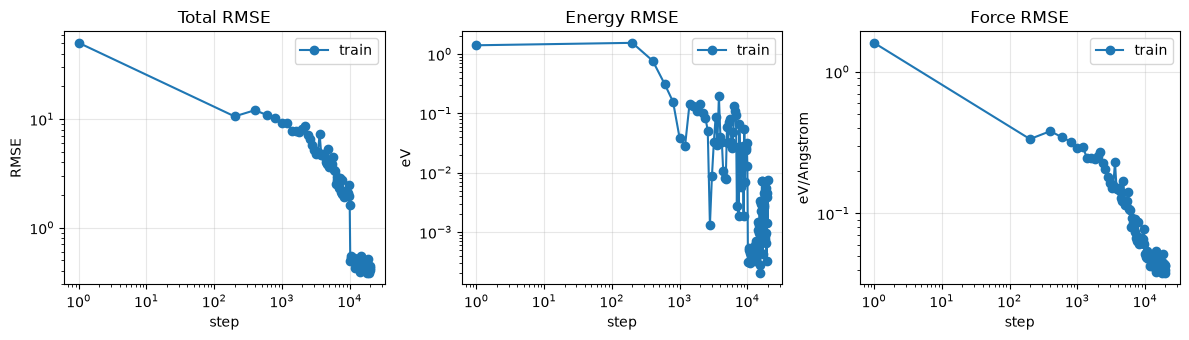

lcurve: runs/cyclohexane_dpa3_distill/student_se_atten_v2/lcurve.out
columns: ['step', 'rmse_trn', 'rmse_e_trn', 'rmse_f_trn', 'lr']
steps: 1 -> 20000


In [18]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

student_workdir = Path("runs/cyclohexane_dpa3_distill/student_se_atten_v2")
lcurve_path = student_workdir / "lcurve.out"
if not lcurve_path.exists():
    raise FileNotFoundError(f"Training curve file not found: {lcurve_path}")

with lcurve_path.open("r", encoding="utf-8") as f:
    header = f.readline().lstrip("#").split()

lcurve = np.atleast_2d(np.loadtxt(lcurve_path))
lcurve_data = {name: lcurve[:, idx] for idx, name in enumerate(header)}
steps = lcurve_data["step"]

metrics = [
    ("rmse_trn", "Total RMSE", "RMSE"),
    ("rmse_e_trn", "Energy RMSE", "eV"),
    ("rmse_f_trn", "Force RMSE", "eV/Angstrom"),
    ("rmse_v_trn", "Virial RMSE", "eV"),
]
metrics = [(key, title, ylabel) for key, title, ylabel in metrics if key in lcurve_data]

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 3.5))
axes = np.atleast_1d(axes)

for ax, (key, title, ylabel) in zip(axes, metrics, strict=False):
    ax.plot(steps, lcurve_data[key], marker="o", label="train")
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_xscale("log")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

print("lcurve:", lcurve_path)
print("columns:", header)
print("steps:", int(steps[0]), "->", int(steps[-1]))

## Freeze and evaluate the Student model on the distillation dataset

After training, export the model and evaluate it against the Teacher labels in the distillation dataset.

**Step 1:** use `dp --pt freeze` to convert the trained checkpoint into a frozen model file under `artifacts/models/`.

**Step 2:** use `dp --pt test` on `data/cyclohexane/train/system_001` to report energy, force, and virial errors. This is a training-set distillation error, not an independent test-set accuracy.


Run `dp --pt freeze` to obtain `student_se_atten_v2.pth`, then compress the exported model.


In [19]:
%%bash
set -euo pipefail

STUDENT_WORKDIR="runs/cyclohexane_dpa3_distill/student_se_atten_v2"
STUDENT_MODEL="$(pwd)/runs/cyclohexane_dpa3_distill/artifacts/models/student_se_atten_v2.pth"
COMPRESSED_MODEL="$(pwd)/runs/cyclohexane_dpa3_distill/artifacts/models/student_compressed.pth"
FREEZE_LOG="runs/cyclohexane_dpa3_distill/artifacts/reports/freeze.log"

mkdir -p "$(dirname "$STUDENT_MODEL")" "$(dirname "$FREEZE_LOG")"

(
  cd "$STUDENT_WORKDIR"
  dp --pt freeze -o "$STUDENT_MODEL"
) > "$FREEZE_LOG" 2>&1

echo "freeze finished: $STUDENT_MODEL"
echo "freeze log: $FREEZE_LOG"

dp --pt compress -i "$STUDENT_MODEL" -o "$COMPRESSED_MODEL"

freeze finished: //runs/cyclohexane_dpa3_distill/artifacts/models/student_se_atten_v2.pth
freeze log: runs/cyclohexane_dpa3_distill/artifacts/reports/freeze.log
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
[2026-06-20 22:44:44,455] DEEPMD INFO    DeePMD version: 3.1.3
[2026-06-20 22:44:44,879] DEEPMD INFO    training data with lower boundary: [[-1.1939386 -0.        -0.        -0.       ]
 [-0.9941983 -0.        -0.        -0.       ]]
[2026-06-20 22:44:44,880] DEEPMD INFO    training data with upper boundary: [[2.3226078 3.9109068 3.9109068 3.9109068]
 [3.28381   5.254691  5.254691  5.254691 ]]


Run `dp --pt test` on the distillation dataset.


In [20]:
%%bash
set -euo pipefail

COMPRESSED_MODEL="$(pwd)/runs/cyclohexane_dpa3_distill/artifacts/models/student_compressed.pth"
TRAIN_SYSTEM="$(pwd)/data/cyclohexane/train/system_001"
TEST_LOG="runs/cyclohexane_dpa3_distill/artifacts/reports/student_train_eval.log"
N_EVAL_FRAMES=1000

mkdir -p "$(dirname "$TEST_LOG")"

dp --pt test -m "$COMPRESSED_MODEL" -s "$TRAIN_SYSTEM" -n "$N_EVAL_FRAMES" > "$TEST_LOG" 2>&1

echo "training-set evaluation finished; log: $TEST_LOG"
echo
echo "Training-set distillation error:"
grep -E "number of test data|Energy MAE|Energy RMSE|Force  MAE|Force  RMSE|Virial MAE|Virial RMSE" "$TEST_LOG" | awk '!seen[$0]++'


training-set evaluation finished; log: runs/cyclohexane_dpa3_distill/artifacts/reports/student_train_eval.log

Training-set distillation error:
[2026-06-20 22:45:02,675] DEEPMD INFO    # number of test data : 501 
[2026-06-20 22:45:02,677] DEEPMD INFO    Energy MAE         : 1.300363e-01 eV
[2026-06-20 22:45:02,677] DEEPMD INFO    Energy RMSE        : 1.301760e-01 eV
[2026-06-20 22:45:02,677] DEEPMD INFO    Energy MAE/Natoms  : 7.224239e-03 eV
[2026-06-20 22:45:02,677] DEEPMD INFO    Energy RMSE/Natoms : 7.231999e-03 eV
[2026-06-20 22:45:02,677] DEEPMD INFO    Force  MAE         : 3.166588e-02 eV/Å
[2026-06-20 22:45:02,677] DEEPMD INFO    Force  RMSE        : 4.142549e-02 eV/Å
[2026-06-20 22:45:02,678] DEEPMD INFO    Energy MAE         : 1.300363e-01 eV
[2026-06-20 22:45:02,678] DEEPMD INFO    Energy RMSE        : 1.301760e-01 eV
[2026-06-20 22:45:02,678] DEEPMD INFO    Energy MAE/Natoms  : 7.224239e-03 eV
[2026-06-20 22:45:02,678] DEEPMD INFO    Energy RMSE/Natoms : 7.231999e-03 eV
[2

## Run MD with the distilled Student model

The frozen and compressed Student model can now be used as an ASE calculator. The default Student MD length is 40,000 steps with a 0.5 fs time step, saving one frame every 100 steps. This gives a longer post-training trajectory while keeping the notebook output size manageable.


In [28]:
STUDENT_MODEL = Path(
    "runs/cyclohexane_dpa3_distill/artifacts/models/student_compressed.pth"
)
STUDENT_MD_TEMPERATURE_K = 300
STUDENT_MD_TIMESTEP_FS = 0.5
STUDENT_MD_STEPS = 40000
STUDENT_SAVE_EVERY = 100

initial_xyz = Path("data/cyclohexane/raw/cyclohexane_initial.xyz")
student_md_xyz = Path("data/cyclohexane/raw/cyclohexane_student.xyz")

from ase.io import write, read
from tqdm import trange
from deepmd.calculator import DP
from ase import units
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet

student_atoms = read(str(initial_xyz))
student_atoms.calc = DP(model=str(STUDENT_MODEL))

rng = np.random.default_rng(20260507)
MaxwellBoltzmannDistribution(
    student_atoms, temperature_K=STUDENT_MD_TEMPERATURE_K, rng=rng
)
student_dynamics = VelocityVerlet(
    student_atoms, timestep=STUDENT_MD_TIMESTEP_FS * units.fs
)

student_md_frames = [student_atoms.copy()]
student_md_energies = [float(student_atoms.get_potential_energy())]

print(
    f"Running Student MD for {STUDENT_MD_STEPS} steps, "
    f"timestep={STUDENT_MD_TIMESTEP_FS} fs, T={STUDENT_MD_TEMPERATURE_K} K"
)

for step in trange(1, STUDENT_MD_STEPS + 1):
    student_dynamics.run(1)
    if step % STUDENT_SAVE_EVERY == 0:
        student_md_frames.append(student_atoms.copy())
        student_md_energies.append(float(student_atoms.get_potential_energy()))

write(str(student_md_xyz), student_md_frames)

print("Student MD finished")
print("saved frames:", len(student_md_frames))
print("trajectory:", student_md_xyz)
print("energy range:", min(student_md_energies), max(student_md_energies), "eV")

You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
Running Student MD for 40000 steps, timestep=0.5 fs, T=300 K
100%|██████████| 40000/40000 [06:19<00:00, 105.40it/s]
Student MD finished
saved frames: 401
trajectory: data/cyclohexane/raw/cyclohexane_student.xyz
energy range: -6417.227179962489 -6416.89055849919 eV


## Visualize representative Student MD structures

This section uses the `student_md_frames` and `student_md_energies` generated above. It selects the lowest-energy and highest-energy saved frames as simple representatives from the Student MD trajectory.

The energy values are the Student model potential energies for the full cyclohexane system in eV. They are not DFT energies and should not be interpreted as a rigorous conformer ranking.

For cyclohexane, a stable room-temperature trajectory is expected to show chair-like structures most of the time. The highest-energy frame in this short trajectory is better described as a distorted structure within the sampled region, not necessarily a true transition-state or boat conformer. To study chair-boat-ring-inversion statistics, run longer sampling, use higher-temperature or enhanced-sampling MD, and validate the resulting structures separately.


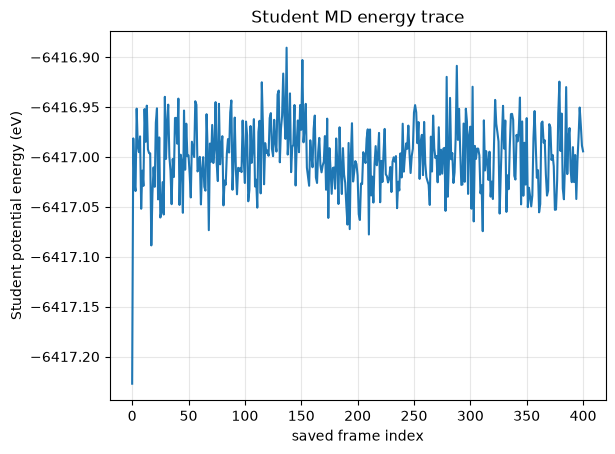

In [31]:
import matplotlib.pyplot as plt

plt.plot(range(len(student_md_energies)), student_md_energies)
plt.xlabel("saved frame index")
plt.ylabel("Student potential energy (eV)")
plt.title("Student MD energy trace")
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
student_md_energies = np.asarray(student_md_energies)

low_idx = int(np.argmin(student_md_energies))
high_idx = int(np.argmax(student_md_energies))

print("trajectory frames:", len(student_md_frames))
print("lowest-energy frame:", low_idx, f"{student_md_energies[low_idx]:.6f} eV")
print("highest-energy frame:", high_idx, f"{student_md_energies[high_idx]:.6f} eV")

view_style = {
    "stick": {"radius": 0.12},
    "sphere": {"radius": 0.35},
}

for label, frame_idx in [
    ("lowest energy", low_idx),
    ("highest energy", high_idx),
]:
    print(f"{label}: frame {frame_idx}, E = {student_md_energies[frame_idx]:.6f} eV")
    view = dpdata.System(student_md_frames[frame_idx], fmt="ase/structure").to_3dmol(
        f_idx=0,
        size=(450, 350),
        style=view_style,
    )
    view.show()

trajectory frames: 401
lowest-energy frame: 0 -6417.227180 eV
highest-energy frame: 137 -6416.890558 eV
lowest energy: frame 0, E = -6417.227180 eV


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

highest energy: frame 137, E = -6416.890558 eV


3Dmol.js failed to load for some reason. Please check your browser console for error messages.